# Property Management Analysis

This notebook analyzes the processed SQL export files for a Property Management Analyst workflow. It focuses on budget variance, AR risk, vendor invoice exceptions, work order backlog, compliance findings, and monthly management reporting KPIs.

Inputs are loaded only from `data/processed`. Chart images are saved to `reports/figures`.

## 1. Executive Overview

The executive overview creates a quick portfolio snapshot for property managers and client stakeholders. It summarizes the latest reporting month, financial performance, AR exposure, invoice exceptions, work order risk, compliance workload, and leasing pipeline value.

In [16]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(FIGURES_DIR / ".mplconfig"))

import pandas as pd

try:
    get_ipython
except NameError:
    import matplotlib
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)
pd.options.display.float_format = "{:,.2f}".format

plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "font.size": 10,
})

ACCENT_GREEN = "#005E5D"
ACCENT_GREEN = "#4C956C"
RISK_RED = "#B23A48"
AMBER = "#C77D00"
DARK_GRAY = "#333333"
LIGHT_GRAY = "#E8E8E8"

def currency_millions(x, _pos=None):
    return f"${x / 1_000_000:,.1f}M"

def currency_short(x, _pos=None):
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x / 1_000:,.0f}K"
    return f"${x:,.0f}"

def save_chart(fig, filename):
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    print(f"Saved chart: {path.relative_to(PROJECT_ROOT)}")
    return path

def render_chart(fig):
    if "agg" in plt.get_backend().lower():
        plt.close(fig)
    else:
        plt.show()

def style_axis(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)

def clean_property_label(value, max_len=42):
    value = str(value)
    return value if len(value) <= max_len else value[: max_len - 3] + "..."

In [17]:
processed_files = {
    "budget": "budget_variance_results.csv",
    "ar": "ar_aging_results.csv",
    "invoice": "invoice_exceptions_results.csv",
    "work_orders": "work_order_backlog_results.csv",
    "compliance": "compliance_reviews_results.csv",
    "monthly": "monthly_management_report_results.csv",
}

missing_files = [name for name in processed_files.values() if not (PROCESSED_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing processed CSV files: {missing_files}")

budget = pd.read_csv(PROCESSED_DIR / processed_files["budget"])
ar = pd.read_csv(PROCESSED_DIR / processed_files["ar"])
invoice = pd.read_csv(PROCESSED_DIR / processed_files["invoice"])
work_orders = pd.read_csv(PROCESSED_DIR / processed_files["work_orders"])
compliance = pd.read_csv(PROCESSED_DIR / processed_files["compliance"])
monthly = pd.read_csv(PROCESSED_DIR / processed_files["monthly"])

monthly["month"] = pd.to_datetime(monthly["month"])
budget["latest_month"] = pd.to_datetime(budget["latest_month"])
ar["latest_ar_month"] = pd.to_datetime(ar["latest_ar_month"])
compliance["month"] = pd.to_datetime(compliance["month"])

loaded_summary = pd.DataFrame([
    {"dataset": file_name, "rows": len(df), "columns": len(df.columns)}
    for file_name, df in [
        (processed_files["budget"], budget),
        (processed_files["ar"], ar),
        (processed_files["invoice"], invoice),
        (processed_files["work_orders"], work_orders),
        (processed_files["compliance"], compliance),
        (processed_files["monthly"], monthly),
    ]
])
display(loaded_summary)

,dataset,rows,columns
0,budget_variance_results.csv,175,32
1,ar_aging_results.csv,2145,20
2,invoice_exceptions_results.csv,17,17
3,work_order_backlog_results.csv,175,22
4,compliance_reviews_results.csv,1118,21
5,monthly_management_report_results.csv,12,39


In [18]:
latest_month = monthly.sort_values("month").iloc[-1]

executive_kpis = pd.DataFrame([
    {"KPI": "Latest reporting month", "Value": latest_month["month"].strftime("%b %Y")},
    {"KPI": "Portfolio NOI", "Value": f"${latest_month['portfolio_noi']:,.0f}"},
    {"KPI": "Portfolio EBITDA", "Value": f"${latest_month['portfolio_ebitda']:,.0f}"},
    {"KPI": "Average occupancy", "Value": f"{latest_month['average_occupancy_rate']:.1%}"},
    {"KPI": "AR outstanding", "Value": f"${latest_month['ar_outstanding_balance']:,.0f}"},
    {"KPI": "Critical AR count", "Value": f"{latest_month['critical_ar_count']:,.0f}"},
    {"KPI": "Invoice exception count", "Value": f"{latest_month['invoice_exception_count']:,.0f}"},
    {"KPI": "Overdue work order count", "Value": f"{latest_month['overdue_work_order_count']:,.0f}"},
    {"KPI": "Open compliance findings", "Value": f"{latest_month['open_compliance_finding_count']:,.0f}"},
    {"KPI": "Primary management focus", "Value": latest_month["primary_management_focus"]},
])

display(executive_kpis)

,KPI,Value
0,Latest reporting month,Dec 2025
1,Portfolio NOI,"$29,900,399"
2,Portfolio EBITDA,"$28,155,519"
3,Average occupancy,93.0%
4,AR outstanding,"$941,879"
5,Critical AR count,11
6,Invoice exception count,241
7,Overdue work order count,58
8,Open compliance findings,98
9,Primary management focus,Compliance and control follow-up


**Business interpretation**

The executive view is designed for a monthly property management meeting. It balances financial performance with operating risk, so stakeholders can see whether the portfolio needs attention on budget variance, collections, vendor controls, maintenance backlog, or compliance follow-up before reviewing property-level detail.

## 2. Budget Variance Analysis

This section identifies properties that are over or under budget and highlights properties with declining NOI or EBITDA. Positive expense variance means actual expenses exceeded budget. Negative income variance means income underperformed budget.

In [19]:
budget_watchlist = budget.sort_values(
    ["budget_variance_priority", "total_expense_variance", "total_income_variance"],
    ascending=[False, False, True],
).head(10)

display(budget_watchlist[[
    "property_id", "property_address", "borough", "property_manager_name",
    "total_income_variance", "income_budget_status",
    "total_expense_variance", "expense_budget_status",
    "latest_noi_change", "noi_trend_status",
    "latest_ebitda_change", "ebitda_trend_status",
    "budget_variance_priority",
]])

,property_id,property_address,borough,property_manager_name,total_income_variance,income_budget_status,total_expense_variance,expense_budget_status,latest_noi_change,noi_trend_status,latest_ebitda_change,ebitda_trend_status,budget_variance_priority
0,PROP-0171,25 CENTRAL PARK WEST,Manhattan,Cameron Brooks,"-2,311,629.90",Under income budget,"1,655,093.03",Over expense budget,"-53,862.66",Declining NOI,"-84,964.61",Declining EBITDA,Management review recommended
1,PROP-0170,465 WEST 23 STREET,Manhattan,Casey Rivera,"-2,722,560.53",Under income budget,"1,534,211.32",Over expense budget,"-1,721.18",Declining NOI,"-12,958.40",Declining EBITDA,Management review recommended
2,PROP-0132,1 CENTRAL PARK WEST,Manhattan,Taylor Morgan,"-1,873,271.43",Under income budget,"1,346,054.19",Over expense budget,"-72,103.47",Declining NOI,"-89,314.73",Declining EBITDA,Management review recommended
3,PROP-0016,252 7 AVENUE,Manhattan,Riley Chen,"-5,801,421.26",Under income budget,"1,278,639.59",Over expense budget,"31,967.97",Improving NOI,"21,298.37",Improving EBITDA,Management review recommended
4,PROP-0097,416 WEST 52 STREET,Manhattan,Casey Rivera,"-859,762.45",Under income budget,"707,946.10",Over expense budget,"-100,371.77",Declining NOI,"-102,054.02",Declining EBITDA,Management review recommended
5,PROP-0135,160 WEST END AVENUE,Manhattan,Avery Johnson,"-1,514,294.92",Under income budget,"604,246.27",Over expense budget,"-51,229.22",Declining NOI,"-37,626.77",Declining EBITDA,Management review recommended
6,PROP-0082,415 EAST 54 STREET,Manhattan,Riley Chen,"-459,958.91",Under income budget,"335,488.08",Over expense budget,"-76,436.00",Declining NOI,"-69,442.81",Declining EBITDA,Management review recommended
7,PROP-0079,200 EAST 94 STREET,Manhattan,Morgan Patel,"-1,595,824.90",Under income budget,"293,711.66",Over expense budget,"134,683.88",Improving NOI,"114,386.86",Improving EBITDA,Management review recommended
8,PROP-0106,467 CENTRAL PARK WEST,Manhattan,Cameron Brooks,"-318,077.60",Under income budget,"283,482.66",Over expense budget,"-18,349.13",Declining NOI,"-19,122.26",Declining EBITDA,Management review recommended
9,PROP-0046,755 KENT AVENUE,Brooklyn,Riley Chen,"-338,462.56",Under income budget,"271,348.51",Over expense budget,"-34,289.01",Declining NOI,"-39,663.20",Declining EBITDA,Management review recommended


Saved chart: reports/figures/budget_variance_top_properties.png


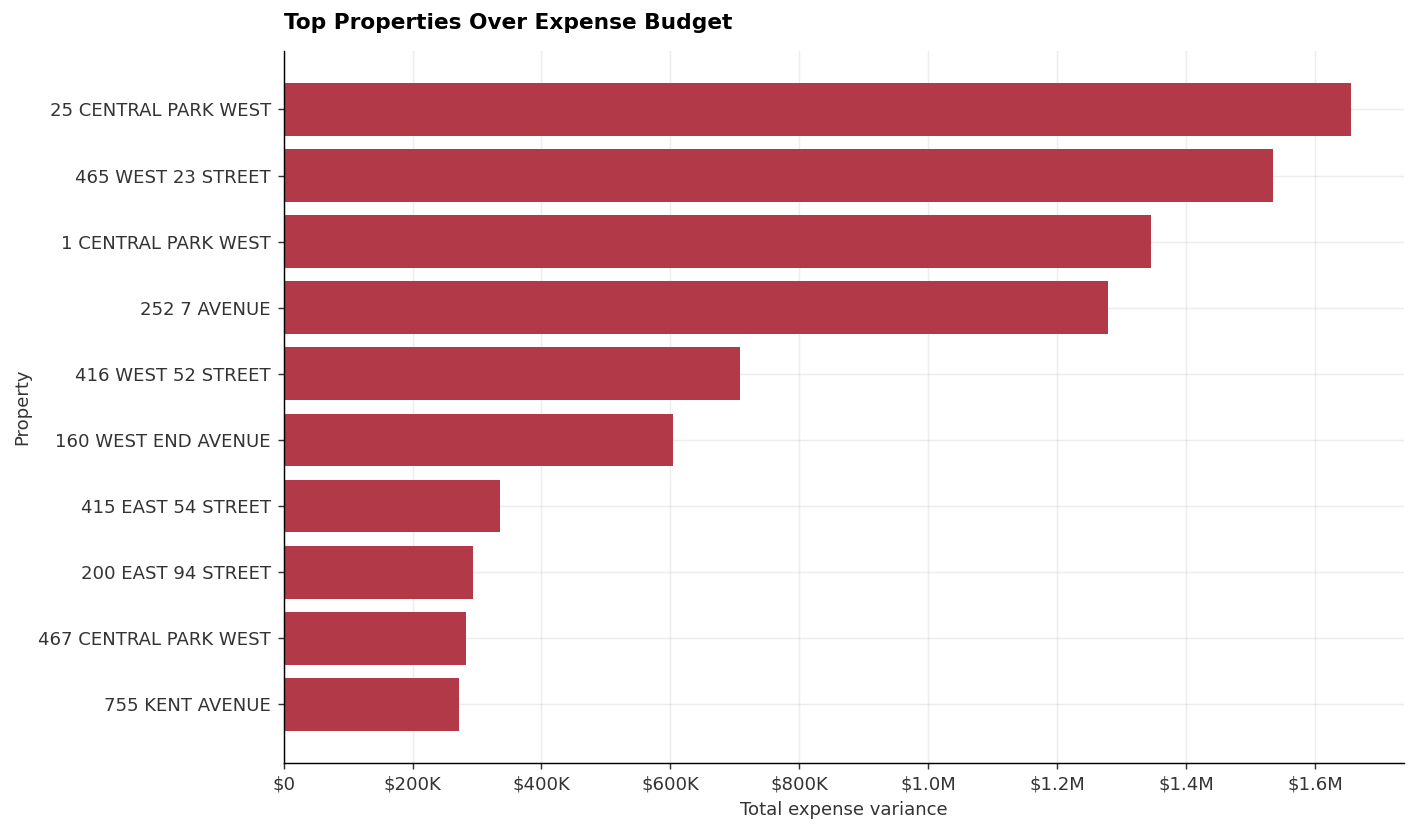

In [20]:
plot_data = budget.nlargest(10, "total_expense_variance").sort_values("total_expense_variance")
labels = plot_data["property_address"].map(clean_property_label)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(labels, plot_data["total_expense_variance"], color=RISK_RED)
ax.xaxis.set_major_formatter(FuncFormatter(currency_short))
style_axis(ax, "Top Properties Over Expense Budget", "Total expense variance", "Property")
save_chart(fig, "budget_variance_top_properties.png")
render_chart(fig)

**Business interpretation**

Properties with expense overages and declining NOI or EBITDA should be reviewed first because they combine operating cost pressure with weakening profitability. Property managers should compare the largest over-budget properties against vendor invoice categories, work order volume, and occupancy trends to identify controllable drivers.

## 3. AR Aging Analysis

This section ranks tenants by current AR exposure and collection risk. The goal is to identify tenants and properties where collection follow-up can protect monthly cash flow.

In [21]:
ar_watchlist = ar.sort_values(
    ["latest_outstanding_balance", "high_or_critical_months", "total_outstanding_balance"],
    ascending=[False, False, False],
).head(12)

display(ar_watchlist[[
    "property_id", "property_address", "property_manager_name",
    "tenant_id", "tenant_name", "tenant_category", "tenant_status",
    "latest_outstanding_balance", "latest_aging_bucket", "latest_collection_priority",
    "months_with_balance", "high_or_critical_months", "ar_risk_status",
]])

,property_id,property_address,property_manager_name,tenant_id,tenant_name,tenant_category,tenant_status,latest_outstanding_balance,latest_aging_bucket,latest_collection_priority,months_with_balance,high_or_critical_months,ar_risk_status
13,PROP-0097,416 WEST 52 STREET,Casey Rivera,TEN-01196,Brightline Group 1196,Residential,Active,"93,441.83",1-30,Medium,12,0,High AR risk
24,PROP-0168,57 READE STREET,Drew Thompson,TEN-02067,Northstar Studio 2067,Retail,Renewal Risk,"68,281.69",61-90,High,12,1,High AR risk
25,PROP-0132,1 CENTRAL PARK WEST,Taylor Morgan,TEN-01601,Northstar Fitness 1601,Healthcare,Active,"67,630.78",61-90,High,12,1,High AR risk
26,PROP-0145,255 WEST 84 STREET,Taylor Morgan,TEN-01772,Cornerstone Clinic 1772,Residential,Renewal Risk,"66,517.26",1-30,Medium,12,0,High AR risk
39,PROP-0082,415 EAST 54 STREET,Riley Chen,TEN-01026,Metro Cafe 1026,Retail,Active,"46,795.10",31-60,Medium,12,1,High AR risk
41,PROP-0079,200 EAST 94 STREET,Morgan Patel,TEN-00983,Urban Design 983,Residential,Active,"44,309.44",1-30,Medium,12,0,High AR risk
42,PROP-0033,550 VANDERBILT AVENUE,Nadia Williams,TEN-00404,Atlas Retail 404,Residential,Active,"41,776.25",61-90,High,12,1,High AR risk
50,PROP-0111,260 PARK AVENUE SOUTH,Casey Rivera,TEN-01371,Evergreen Design 1371,Residential,Active,"33,827.53",31-60,Medium,12,0,High AR risk
53,PROP-0132,1 CENTRAL PARK WEST,Taylor Morgan,TEN-01608,Harbor Services 1608,Residential,Active,"32,036.91",1-30,Medium,12,0,High AR risk
65,PROP-0088,148 EAST 24 STREET,Taylor Morgan,TEN-01114,Parkside Design 1114,Residential,Active,"23,035.43",1-30,Medium,12,0,High AR risk


Saved chart: reports/figures/ar_aging_high_risk_tenants.png


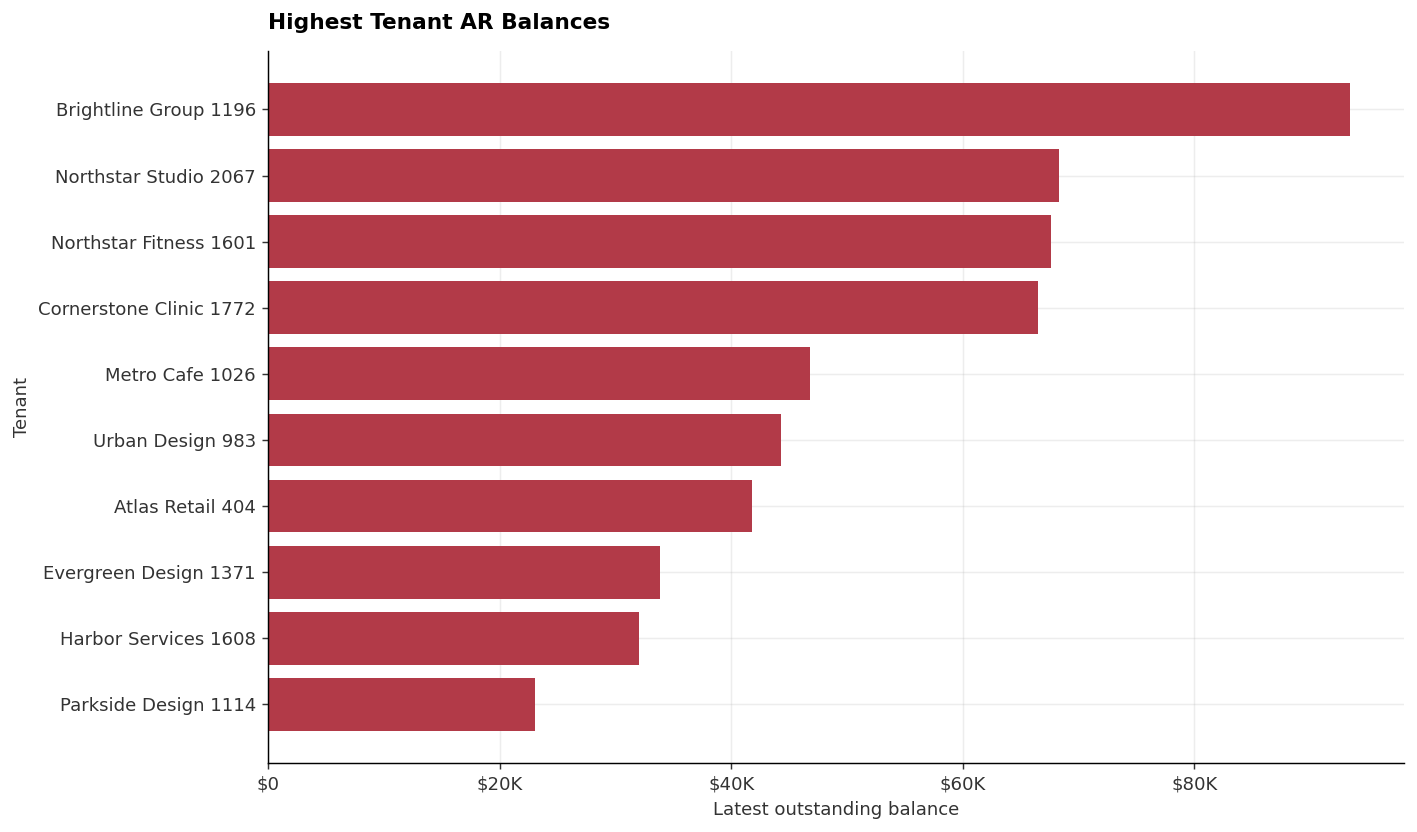

In [22]:
plot_data = ar.nlargest(10, "latest_outstanding_balance").sort_values("latest_outstanding_balance")
labels = plot_data["tenant_name"].map(clean_property_label)
colors = [RISK_RED if status in ["Critical AR risk", "High AR risk"] else AMBER for status in plot_data["ar_risk_status"]]

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(labels, plot_data["latest_outstanding_balance"], color=colors)
ax.xaxis.set_major_formatter(FuncFormatter(currency_short))
style_axis(ax, "Highest Tenant AR Balances", "Latest outstanding balance", "Tenant")
save_chart(fig, "ar_aging_high_risk_tenants.png")
render_chart(fig)

**Business interpretation**

The highest-risk tenants are those with large outstanding balances, severe aging buckets, or repeated high and critical collection priority months. Property managers should coordinate with client accounting and leasing teams to confirm payment plans, lease status, renewal risk, and any operational issues that may be delaying payment.

## 4. Vendor Invoice Exception Analysis

This section identifies vendors with the highest invoice exception workload. It separates compliance exceptions, late payments, potential duplicate review cases, missing GL codes, pending approvals, and rejected invoices.

In [23]:
vendor_watchlist = invoice.sort_values(
    ["exception_invoice_count", "exception_rate_pct", "total_invoice_amount"],
    ascending=[False, False, False],
).head(10)

display(vendor_watchlist[[
    "vendor_id", "vendor_name", "default_invoice_category", "invoice_count",
    "total_invoice_amount", "exception_invoice_count", "exception_rate_pct",
    "late_payment_count", "potential_duplicate_review_count", "missing_gl_code_count",
    "pending_approval_count", "rejected_invoice_count", "vendor_exception_status",
]])

,vendor_id,vendor_name,default_invoice_category,invoice_count,total_invoice_amount,exception_invoice_count,exception_rate_pct,late_payment_count,potential_duplicate_review_count,missing_gl_code_count,pending_approval_count,rejected_invoice_count,vendor_exception_status
0,VEND-017,OfficeWorks Supply,Administrative,665,"489,065.00",212,31.90,98,12,19,80,20,High vendor exception workload
1,VEND-012,Sparkle Janitorial,Janitorial,643,"2,083,740.83",187,29.10,84,17,16,73,24,High vendor exception workload
2,VEND-006,ConEd Utility,Utilities,593,"2,365,992.42",185,31.20,86,13,22,65,19,High vendor exception workload
3,VEND-002,Skyline Maintenance,Repairs & Maintenance,617,"3,177,182.52",183,29.70,80,11,28,64,19,High vendor exception workload
4,VEND-001,Rapid Repair Co,Repairs & Maintenance,602,"2,707,421.21",181,30.10,77,11,19,74,24,High vendor exception workload
5,VEND-015,ComplianceWorks,Professional Services,620,"989,796.75",179,28.90,69,12,21,72,23,High vendor exception workload
6,VEND-005,Bright Electric,Repairs & Maintenance,650,"3,351,348.59",179,27.50,77,14,23,72,12,High vendor exception workload
7,VEND-003,Metro Mechanical,Repairs & Maintenance,651,"3,589,187.70",176,27.00,78,16,22,64,14,High vendor exception workload
8,VEND-009,Guardian Security,Security,605,"1,139,344.87",174,28.80,78,9,16,72,15,High vendor exception workload
9,VEND-007,NY Water Services,Utilities,620,"2,247,003.10",174,28.10,72,12,22,63,28,High vendor exception workload


Saved chart: reports/figures/vendor_invoice_exceptions_by_vendor.png


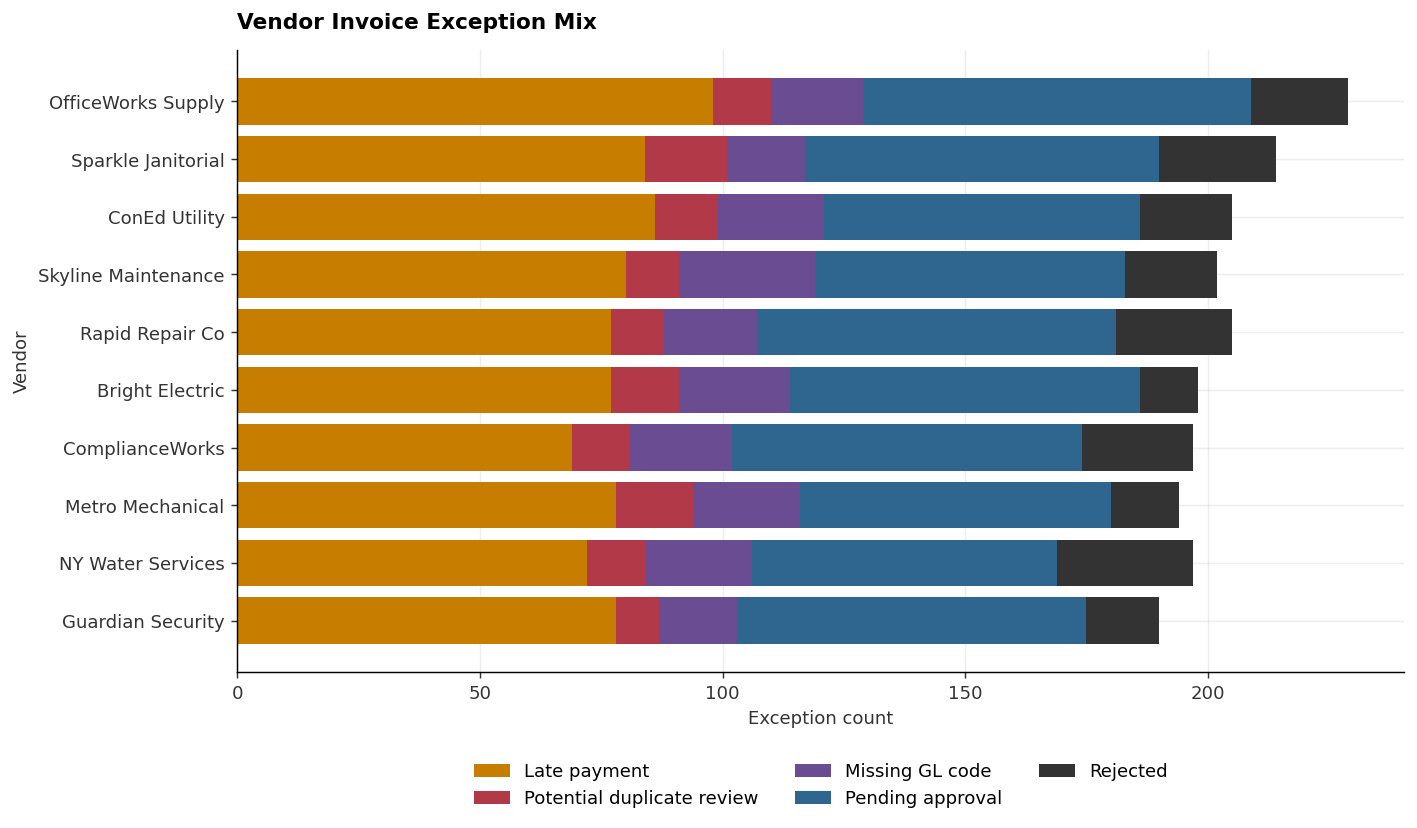

In [24]:
plot_data = invoice.nlargest(10, "exception_invoice_count").sort_values("exception_invoice_count")
labels = plot_data["vendor_name"].map(clean_property_label)

fig, ax = plt.subplots(figsize=(11, 6.5))
left = pd.Series([0] * len(plot_data), index=plot_data.index, dtype="float")
components = [
    ("late_payment_count", "Late payment", AMBER),
    ("potential_duplicate_review_count", "Potential duplicate review", RISK_RED),
    ("missing_gl_code_count", "Missing GL code", "#6A4C93"),
    ("pending_approval_count", "Pending approval", "#2F6690"),
    ("rejected_invoice_count", "Rejected", DARK_GRAY),
]

for column, label, color in components:
    ax.barh(labels, plot_data[column], left=left, label=label, color=color)
    left = left + plot_data[column]

style_axis(ax, "Vendor Invoice Exception Mix", "Exception count", "Vendor")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
save_chart(fig, "vendor_invoice_exceptions_by_vendor.png")
render_chart(fig)

**Business interpretation**

Vendors with high exception counts should be prioritized for invoice process review. Potential duplicate invoice review cases are not confirmed duplicates; they are control flags that should trigger supporting documentation review, approval trail checks, and vendor communication before payment or month-end close.

## 5. Work Order Backlog Analysis

This section highlights properties with active backlog, overdue work orders, and critical or high-priority maintenance exposure. The view supports SLA management and property operations follow-up.

In [25]:
backlog_watchlist = work_orders.sort_values(
    ["overdue_active_backlog_count", "active_backlog_count", "critical_priority_count"],
    ascending=[False, False, False],
).head(12)

display(backlog_watchlist[[
    "property_id", "property_address", "borough", "property_manager_name",
    "active_backlog_count", "open_work_orders", "in_progress_work_orders",
    "overdue_work_orders", "overdue_active_backlog_count",
    "critical_priority_count", "high_priority_count", "largest_active_backlog_category",
    "estimated_work_order_cost", "backlog_status",
]])

,property_id,property_address,borough,property_manager_name,active_backlog_count,open_work_orders,in_progress_work_orders,overdue_work_orders,overdue_active_backlog_count,critical_priority_count,high_priority_count,largest_active_backlog_category,estimated_work_order_cost,backlog_status
0,PROP-0170,465 WEST 23 STREET,Manhattan,Casey Rivera,19,10,9,24,9,3,12,Elevator,"54,035.61",Immediate backlog review
1,PROP-0135,160 WEST END AVENUE,Manhattan,Avery Johnson,17,11,6,17,8,4,15,HVAC,"43,637.86",Immediate backlog review
2,PROP-0171,25 CENTRAL PARK WEST,Manhattan,Cameron Brooks,20,9,11,16,7,5,14,HVAC,"42,325.16",Immediate backlog review
3,PROP-0016,252 7 AVENUE,Manhattan,Riley Chen,12,4,8,14,7,6,8,Elevator,"39,840.59",Immediate backlog review
4,PROP-0002,7 NAVY PIER COURT,Staten Island,Cameron Brooks,23,13,10,13,6,0,15,Janitorial,"40,051.37",Immediate backlog review
5,PROP-0097,416 WEST 52 STREET,Manhattan,Casey Rivera,14,6,8,10,5,4,6,Common Area,"20,556.47",Immediate backlog review
6,PROP-0079,200 EAST 94 STREET,Manhattan,Morgan Patel,14,9,5,11,5,3,9,Elevator,"29,227.13",Immediate backlog review
7,PROP-0084,886 WESTCHESTER AVENUE,Bronx,Avery Johnson,14,7,7,10,5,1,5,Preventive Maintenance,"17,631.74",Immediate backlog review
8,PROP-0169,885 AVENUE OF THE AMERICA,Manhattan,Samira Khan,12,6,6,12,5,0,12,Electrical,"25,479.89",Immediate backlog review
9,PROP-0122,27 KING STREET,Manhattan,Cameron Brooks,8,1,7,9,5,2,6,Electrical,"20,980.02",Immediate backlog review


Saved chart: reports/figures/work_order_backlog_by_property.png


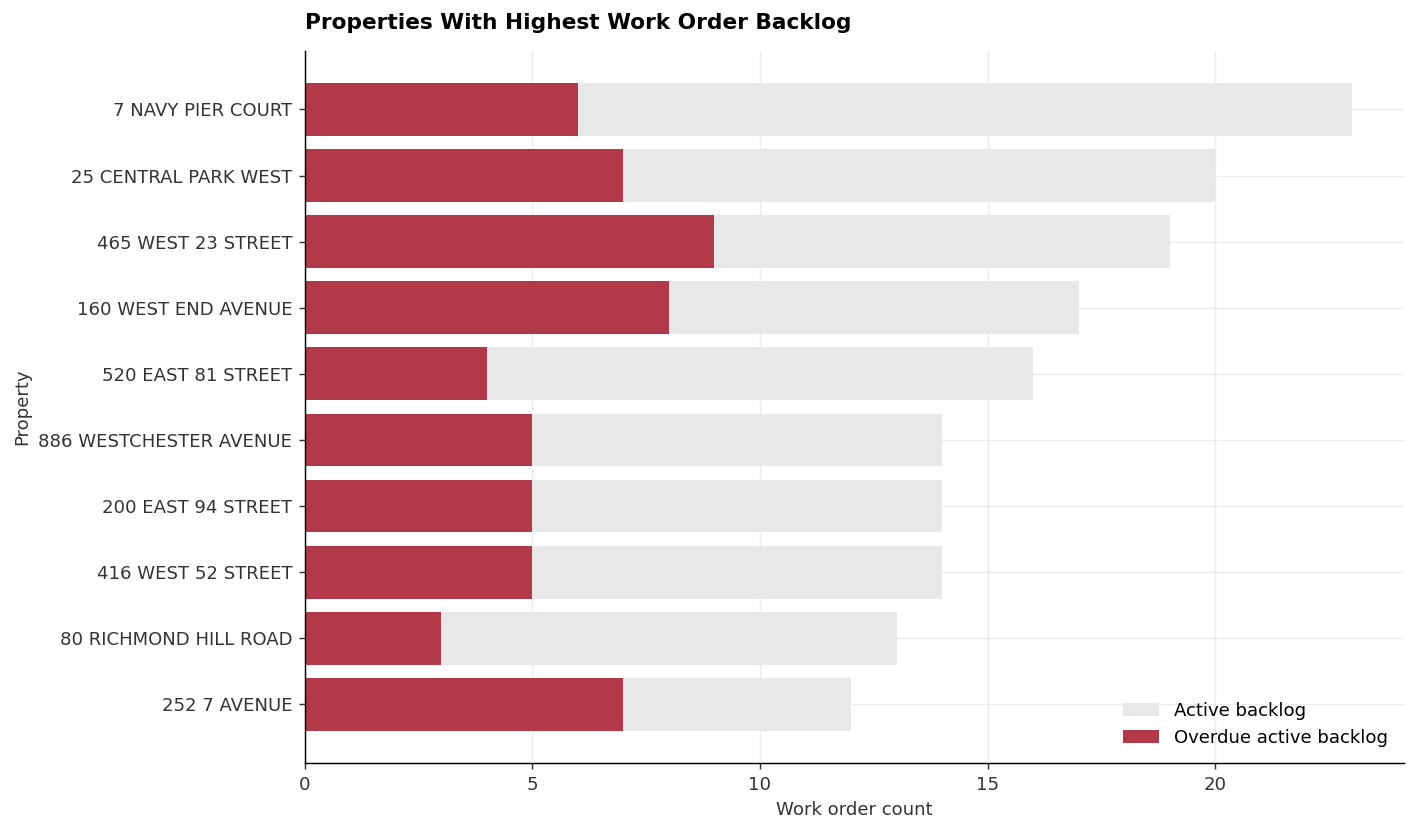

In [26]:
plot_data = work_orders.nlargest(10, "active_backlog_count").sort_values("active_backlog_count")
labels = plot_data["property_address"].map(clean_property_label)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(labels, plot_data["active_backlog_count"], color=LIGHT_GRAY, label="Active backlog")
ax.barh(labels, plot_data["overdue_active_backlog_count"], color=RISK_RED, label="Overdue active backlog")
style_axis(ax, "Properties With Highest Work Order Backlog", "Work order count", "Property")
ax.legend(loc="lower right", frameon=False)
save_chart(fig, "work_order_backlog_by_property.png")
render_chart(fig)

**Business interpretation**

Backlog pressure should be reviewed alongside tenant impact and vendor assignment. Properties with overdue active backlog or critical work orders need faster escalation because unresolved maintenance can affect tenant satisfaction, operating risk, and client perception of service quality.

## 6. Compliance Review Analysis

This section summarizes unresolved compliance findings by property manager, property, severity, and issue type. It supports follow-up planning for open findings and control exceptions.

In [27]:
manager_compliance = (
    compliance.groupby("property_manager_name", as_index=False)
    .agg(
        open_finding_count=("review_id", "count"),
        high_severity_open_count=("severity", lambda s: (s == "High").sum()),
        properties_with_open_findings=("property_id", "nunique"),
    )
    .sort_values(["high_severity_open_count", "open_finding_count"], ascending=[False, False])
)

display(manager_compliance.head(10))

display(compliance.sort_values(
    ["manager_high_severity_open_count", "manager_open_finding_count", "severity"],
    ascending=[False, False, True],
).head(12)[[
    "review_id", "month", "property_id", "property_address", "property_manager_name",
    "review_type", "issue_category", "severity", "status", "recommended_follow_up_priority",
]])

,property_manager_name,open_finding_count,high_severity_open_count,properties_with_open_findings
9,Taylor Morgan,152,48,22
3,Drew Thompson,124,43,20
0,Avery Johnson,108,40,17
7,Riley Chen,137,39,21
1,Cameron Brooks,130,37,16
6,Nadia Williams,98,36,13
4,Jordan Lee,134,35,22
2,Casey Rivera,91,30,14
8,Samira Khan,84,28,16
5,Morgan Patel,60,15,12


,review_id,month,property_id,property_address,property_manager_name,review_type,issue_category,severity,status,recommended_follow_up_priority
0,REV-0001236,2025-12-01,PROP-0115,25-47 23 STREET,Taylor Morgan,Monthly Financial Review,Income below budget,High,In Review,High priority follow-up
1,REV-0001867,2025-12-01,PROP-0140,80 RICHMOND HILL ROAD,Taylor Morgan,Operations/SLA Review,Overdue work order,High,Open,Immediate action
2,REV-0001804,2025-12-01,PROP-0145,255 WEST 84 STREET,Taylor Morgan,Operations/SLA Review,Overdue work order,High,In Review,High priority follow-up
3,REV-0001252,2025-11-01,PROP-0005,680 RIVERSIDE DRIVE,Taylor Morgan,Monthly Financial Review,Expense over budget,High,Open,Immediate action
4,REV-0001458,2025-11-01,PROP-0054,35 WEST END AVENUE,Taylor Morgan,Monthly Financial Review,Income below budget,High,In Review,High priority follow-up
5,REV-0002099,2025-11-01,PROP-0115,25-47 23 STREET,Taylor Morgan,Operations/SLA Review,Overdue work order,High,In Review,High priority follow-up
6,REV-0001903,2025-11-01,PROP-0140,80 RICHMOND HILL ROAD,Taylor Morgan,Operations/SLA Review,Overdue work order,High,Open,Immediate action
7,REV-0001578,2025-10-01,PROP-0043,376 WALLABOUT STREET,Taylor Morgan,Monthly Financial Review,Income below budget,High,In Review,High priority follow-up
8,REV-0001949,2025-10-01,PROP-0048,220 WEST 148 STREET,Taylor Morgan,Operations/SLA Review,Overdue work order,High,Open,Immediate action
9,REV-0002162,2025-10-01,PROP-0054,35 WEST END AVENUE,Taylor Morgan,Operations/SLA Review,Overdue work order,High,Open,Immediate action


Saved chart: reports/figures/compliance_open_findings_by_manager.png


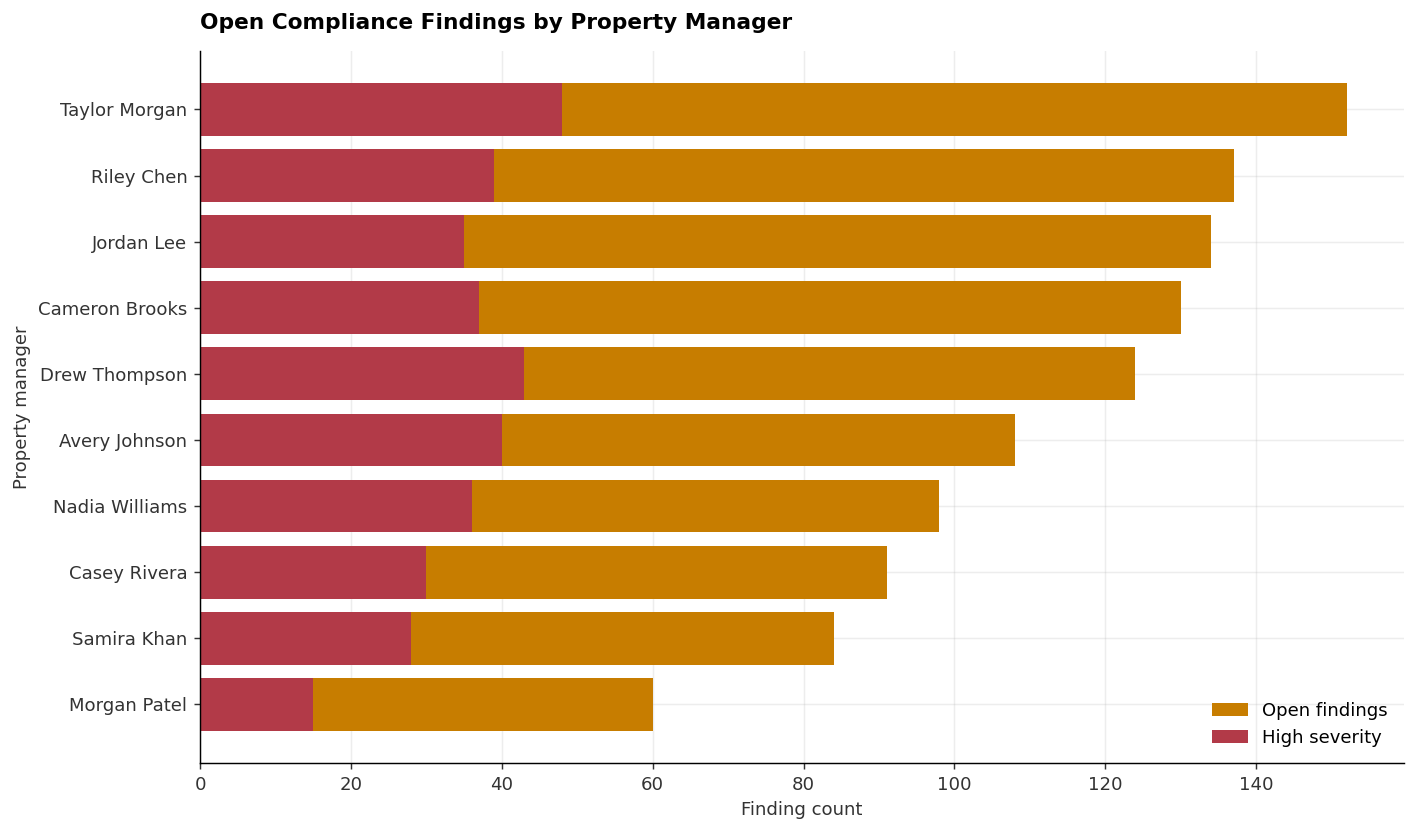

In [28]:
plot_data = manager_compliance.head(10).sort_values("open_finding_count")

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(plot_data["property_manager_name"], plot_data["open_finding_count"], color=AMBER, label="Open findings")
ax.barh(plot_data["property_manager_name"], plot_data["high_severity_open_count"], color=RISK_RED, label="High severity")
style_axis(ax, "Open Compliance Findings by Property Manager", "Finding count", "Property manager")
ax.legend(loc="lower right", frameon=False)
save_chart(fig, "compliance_open_findings_by_manager.png")
render_chart(fig)

**Business interpretation**

Property managers with the largest open finding workload may need prioritization support, especially when high-severity findings are concentrated across multiple properties. Client stakeholders should track whether open items are moving from `Open` or `In Review` to `Resolved` before the next reporting cycle.

## 7. Monthly Management Report KPIs

This section converts the monthly SQL export into a management reporting view. The KPIs combine financial performance, collections, vendor controls, work order service levels, compliance findings, and leasing pipeline indicators.

In [29]:
monthly_display = monthly.copy()
monthly_display["month"] = monthly_display["month"].dt.strftime("%Y-%m")

display(monthly_display[[
    "month", "portfolio_noi", "portfolio_ebitda", "average_occupancy_rate",
    "ar_outstanding_balance", "critical_ar_count", "high_ar_count",
    "invoice_exception_count", "late_invoice_count", "potential_duplicate_review_count",
    "overdue_work_order_count", "open_compliance_finding_count",
    "weighted_monthly_rent", "primary_management_focus",
]])

,month,portfolio_noi,portfolio_ebitda,average_occupancy_rate,ar_outstanding_balance,critical_ar_count,high_ar_count,invoice_exception_count,late_invoice_count,potential_duplicate_review_count,overdue_work_order_count,open_compliance_finding_count,weighted_monthly_rent,primary_management_focus
0,2025-01,"30,197,950.73","28,558,778.63",0.93,"2,069,729.08",7,18,266,115,17,61,92,"55,678.12",Compliance and control follow-up
1,2025-02,"30,601,988.58","28,876,324.20",0.93,"1,393,452.50",6,20,239,96,14,66,94,"196,670.00",Compliance and control follow-up
2,2025-03,"30,657,898.41","29,019,141.62",0.93,"1,175,528.62",9,20,250,107,16,57,81,"79,220.05",Compliance and control follow-up
3,2025-04,"31,214,064.90","29,490,851.89",0.93,"909,169.05",7,16,212,95,16,65,94,"70,769.93",Compliance and control follow-up
4,2025-05,"31,206,386.47","29,463,937.19",0.93,"1,055,031.51",7,13,255,108,18,65,92,"34,609.70",Compliance and control follow-up
5,2025-06,"31,607,472.72","29,860,180.96",0.93,"982,841.69",10,13,235,96,9,80,92,"200,562.72",Compliance and control follow-up
6,2025-07,"31,081,648.48","29,377,067.50",0.93,"1,328,000.66",7,13,270,124,12,68,107,"40,155.32",Compliance and control follow-up
7,2025-08,"30,791,195.34","29,058,991.43",0.93,"1,385,646.10",9,18,259,123,15,75,96,"82,330.12",Compliance and control follow-up
8,2025-09,"30,246,044.00","28,547,008.56",0.94,"1,173,760.31",13,20,241,93,24,51,91,"43,042.16",Compliance and control follow-up
9,2025-10,"30,359,427.43","28,598,883.73",0.93,"1,429,065.59",14,17,273,128,23,73,91,"85,834.79",Compliance and control follow-up


Saved chart: reports/figures/monthly_financial_kpis.png


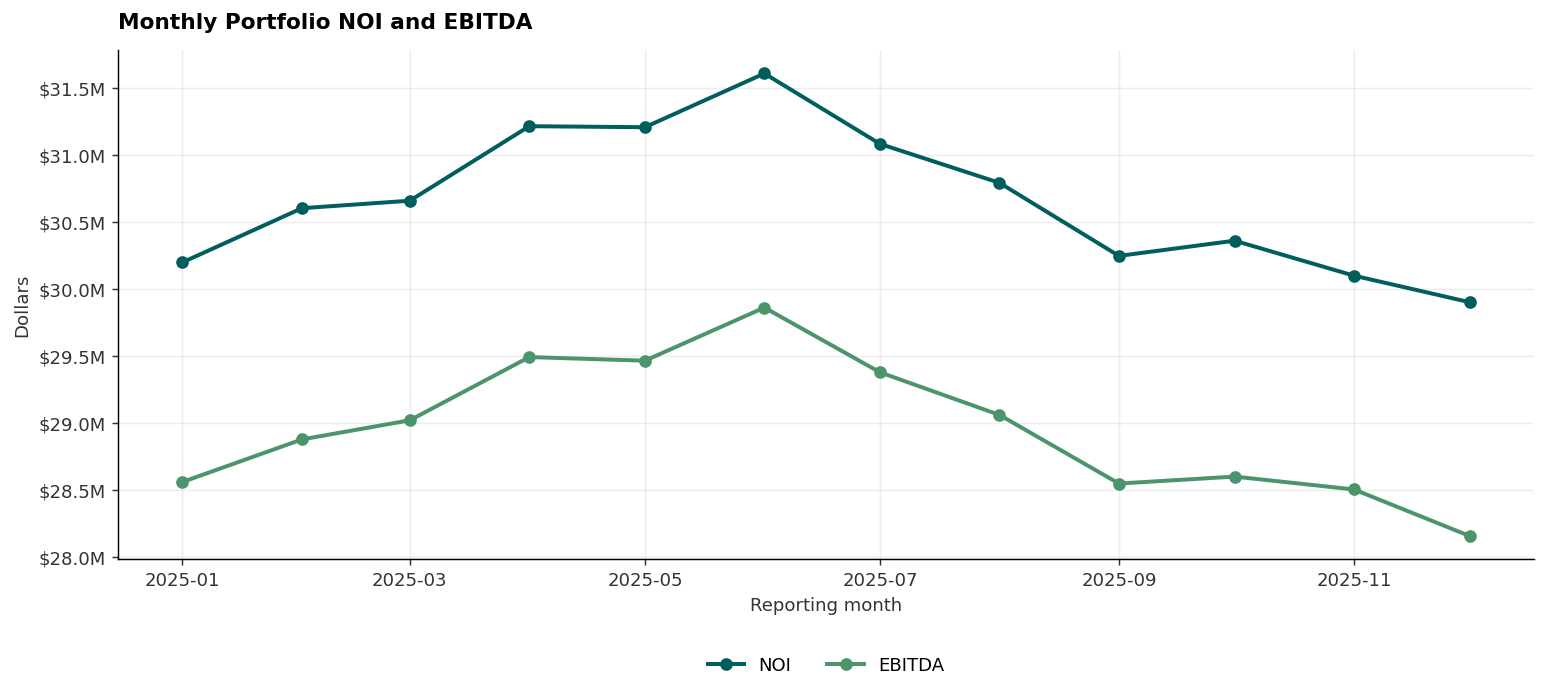

Saved chart: reports/figures/monthly_ar_outstanding.png


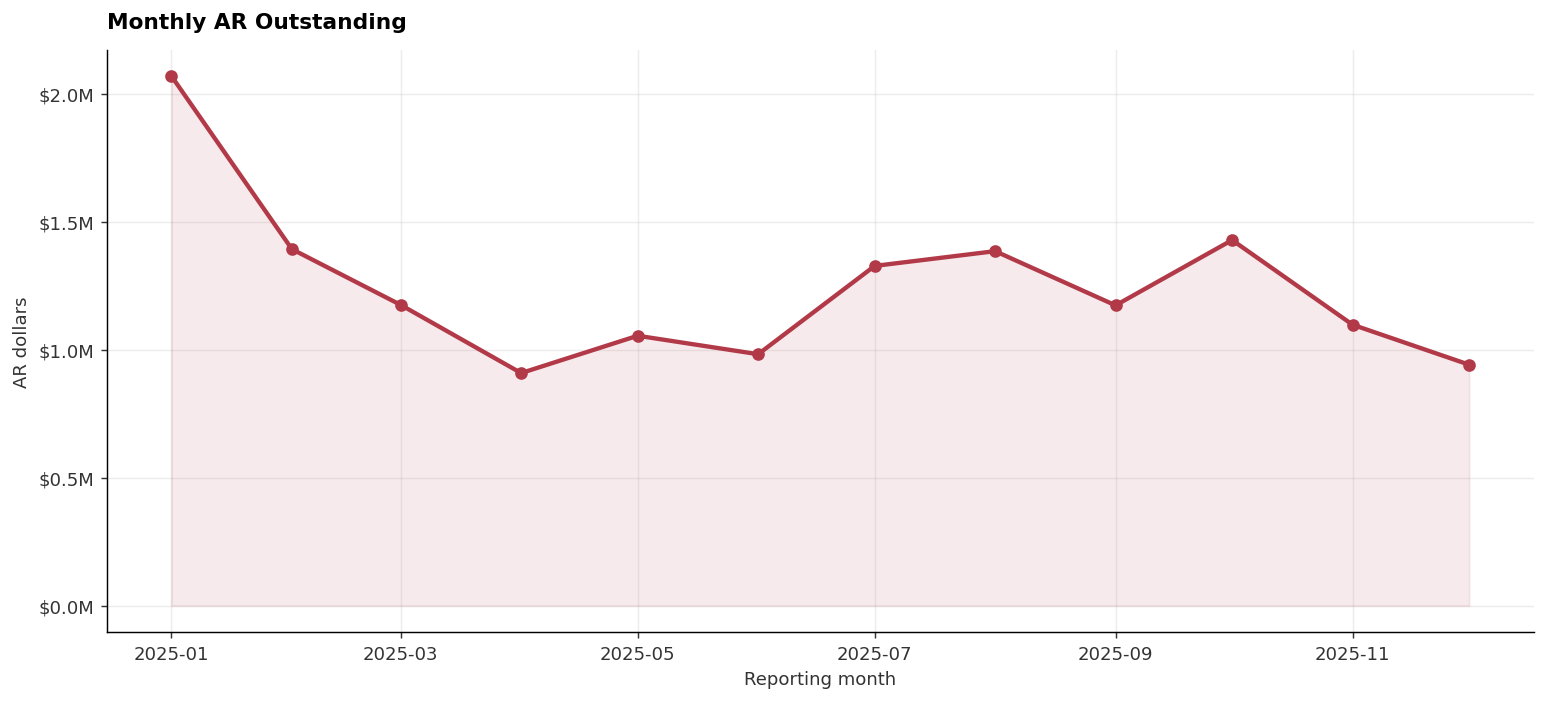

Saved chart: reports/figures/monthly_operating_risk_counts.png


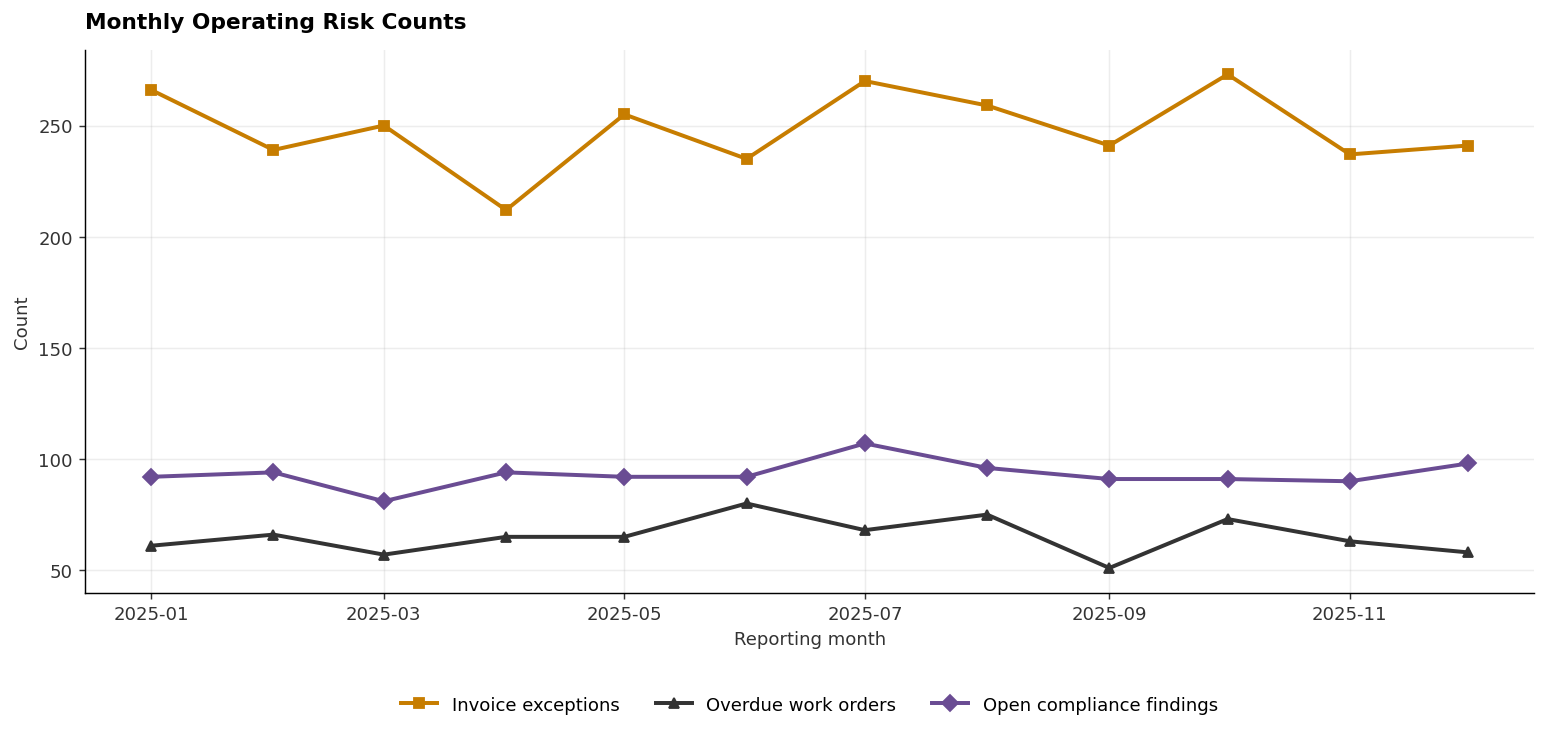

In [30]:
# Remove the older combined chart if it exists so the figures folder only shows the cleaner split view.
old_combined_chart = FIGURES_DIR / "monthly_management_kpis.png"
if old_combined_chart.exists():
    old_combined_chart.unlink()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(monthly["month"], monthly["portfolio_noi"], marker="o", linewidth=2.2, color=ACCENT_GREEN, label="NOI")
ax.plot(monthly["month"], monthly["portfolio_ebitda"], marker="o", linewidth=2.2, color=ACCENT_GREEN, label="EBITDA")
ax.yaxis.set_major_formatter(FuncFormatter(currency_millions))
style_axis(ax, "Monthly Portfolio NOI and EBITDA", "Reporting month", "Dollars")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
save_chart(fig, "monthly_financial_kpis.png")
render_chart(fig)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(monthly["month"], monthly["ar_outstanding_balance"], marker="o", linewidth=2.4, color=RISK_RED)
ax.fill_between(monthly["month"], monthly["ar_outstanding_balance"], color=RISK_RED, alpha=0.10)
ax.yaxis.set_major_formatter(FuncFormatter(currency_millions))
style_axis(ax, "Monthly AR Outstanding", "Reporting month", "AR dollars")
save_chart(fig, "monthly_ar_outstanding.png")
render_chart(fig)

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(monthly["month"], monthly["invoice_exception_count"], marker="s", linewidth=2.2, color=AMBER, label="Invoice exceptions")
ax.plot(monthly["month"], monthly["overdue_work_order_count"], marker="^", linewidth=2.2, color=DARK_GRAY, label="Overdue work orders")
ax.plot(monthly["month"], monthly["open_compliance_finding_count"], marker="D", linewidth=2.2, color="#6A4C93", label="Open compliance findings")
style_axis(ax, "Monthly Operating Risk Counts", "Reporting month", "Count")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, frameon=False)
save_chart(fig, "monthly_operating_risk_counts.png")
render_chart(fig)

**Business interpretation**

The monthly management report should lead with NOI, EBITDA, occupancy, AR exposure, invoice exception workload, work order backlog, compliance findings, and leasing pipeline value. The `primary_management_focus` field is useful as a concise talking point for each month, but stakeholders should still review the supporting detail tables before deciding on actions.

## 8. Final Recommendations

**For property managers**

- Review properties with expense overages and declining NOI or EBITDA before month-end close.
- Prioritize AR follow-up for tenants with critical collection priority, severe aging, or repeated high-risk months.
- Use the vendor exception view to tighten approval routing, GL coding discipline, and documentation review.
- Escalate properties with overdue active work order backlog or critical priority work orders.
- Close high-severity compliance findings first and document the resolution path for client review.

**For client stakeholders**

- Use the monthly KPI table as the executive reporting layer and the section-level views as drill-down support.
- Treat `potential_duplicate_review_count` as a control workload metric, not as confirmed duplicate invoices.
- Monitor whether recurring budget pressure is tied to controllable operating expenses, vendor behavior, occupancy, or one-time maintenance items.
- Track open compliance findings, overdue work orders, and AR exposure together because they represent operational, financial, and control risk.
- Refresh the SQL exports and rerun this notebook each month to maintain a repeatable reporting process.